In [1]:
!pip install sentence-transformers seaborn scikit-learn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
sentences = [

# Cricket
"The cricket match was thrilling until the last over.",
"The batsman scored a century in the final match.",
"The bowler delivered a perfect yorker to take the wicket.",
"The team celebrated their victory after the intense cricket match.",

# Cooking
"I love cooking pasta with fresh tomato sauce.",
"Baking a chocolate cake requires precise measurements.",
"The chef prepared a delicious meal using fresh vegetables.",

# Cybersecurity
"Cybersecurity protects systems from digital attacks.",
"Strong passwords help prevent unauthorized access.",
"Phishing attacks trick users into revealing sensitive information."

]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


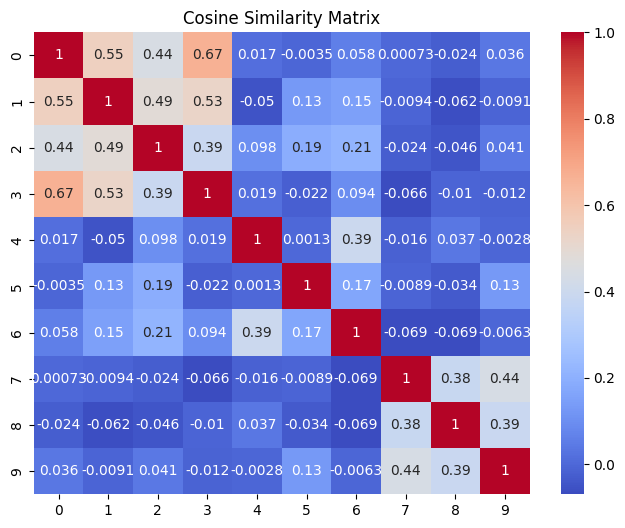

In [5]:
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)
df

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(query_similarity)[-2:][::-1]

print("Query:", query)

for i in top_indices:
    print("\nSentence:", sentences[i])
    print("Similarity Score:", query_similarity[i])

Query: The bowler took three wickets in one over

Sentence: The bowler delivered a perfect yorker to take the wicket.
Similarity Score: 0.6850507

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679121
